# First glance to SSHA wavenumber

In [1]:
import xarray as xr
import numpy as np
import xrft

import matplotlib.pyplot as plt
from scipy import signal

In [2]:
#Loading file
data_dir = "/Users/zoecas/Documents/data/"
filename = "SWOT_L2_LR_SSH_BASIC_D_D-20260603_062409/SWOT_L2_LR_SSH_Basic_044_098_20260106T210232_20260106T215400_PID0_01.nc"

In [3]:
ds = xr.open_dataset(data_dir+filename)
ds

<xarray.Dataset> Size: 112MB
Dimensions:                                (num_lines: 9866, num_pixels: 69,
                                            num_sides: 2)
Coordinates:
    latitude                               (num_lines, num_pixels) float64 5MB ...
    longitude                              (num_lines, num_pixels) float64 5MB ...
Dimensions without coordinates: num_lines, num_pixels, num_sides
Data variables: (12/24)
    time                                   (num_lines) datetime64[ns] 79kB ...
    time_tai                               (num_lines) datetime64[ns] 79kB ...
    ssh_karin                              (num_lines, num_pixels) float64 5MB ...
    ssh_karin_qual                         (num_lines, num_pixels) float64 5MB ...
    ssh_karin_uncert                       (num_lines, num_pixels) float64 5MB ...
    ssha_karin                             (num_lines, num_pixels) float64 5MB ...
    ...                                     ...
    mean_sea_surface_cnescls               (num_lines, num_pixels) float64 5MB ...
    mean_sea_surface_cnescls_uncert        (num_lines, num_pixels) float64 5MB ...
    geoid                                  (num_lines, num_pixels) float64 5MB ...
    internal_tide_hret                     (num_lines, num_pixels) float64 5MB ...
    height_cor_xover                       (num_lines, num_pixels) float64 5MB ...
    height_cor_xover_qual                  (num_lines, num_pixels) float32 3MB ...
Attributes: (12/62)
    Conventions:                                   CF-1.7
    title:                                         Level 2 Low Rate Sea Surfa...
    institution:                                   CNES
    source:                                        Ka-band radar interferometer
    history:                                       2026-01-08T16:17:27Z : Cre...
    platform:                                      SWOT
    ...                                            ...
    ellipsoid_semi_major_axis:                     6378137.0
    ellipsoid_flattening:                          0.0033528106647474805
    good_ocean_data_percent:                       67.80712455934498
    ssha_variance:                                 0.026332454950334927
    references:                                    V1.4.1
    equator_longitude:                             4.50

In [4]:
#Tilt correction
ssh = ds["ssha_karin"] + ds["height_cor_xover"]

#Extracting cross_tack
cross_idx = 50
ssh_line = ssh.isel(num_pixels=cross_idx)
ssh_line.values

array([nan, nan, nan, ..., nan, nan, nan], shape=(9866,))

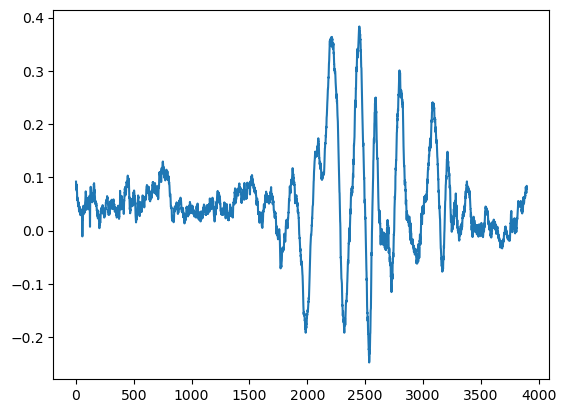

In [6]:
#Selecting part of the track
ssh_line = ssh_line.sel(num_lines=slice(4600,8500))
ssh_line = ssh_line.where(np.abs(ssh_line)<1).where(np.isfinite(ssh_line),drop=True)
ssh_line = ssh_line.where(np.isnan(ssh_line)==False,drop=True)
plt.plot(ssh_line)

In [7]:
# Spectra computation
dx = 2000.0
n = ssh_line.size

x = np.arange(n) * dx


ssh_line = ssh_line.assign_coords(distance=("num_lines", x))
ssh_line = ssh_line.swap_dims({"num_lines": "distance"})


ssh_detrended = xr.DataArray(
    signal.detrend(ssh_line.values),
    dims=["distance"],
    coords={"distance": x},
)

window = signal.windows.hann(n)

ssh_windowed = ssh_detrended * window

In [8]:
fft = xrft.power_spectrum(
    ssh_windowed,
    dim="distance",
    detrend=None,
    #window_correction=False,
    true_phase=False,
    true_amplitude=True,
)

In [9]:
k = fft["freq_distance"]

mask = k > 0

kpos = k.where(mask, drop=True)
psd = fft.where(mask, drop=True)

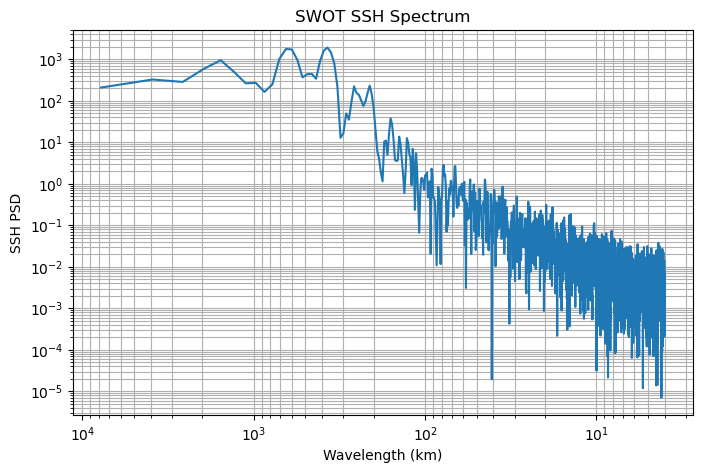

In [11]:

plt.figure(figsize=(8,5))

plt.loglog(wavelength_km, psd)

plt.gca().invert_xaxis()

plt.xlabel("Wavelength (km)")
plt.ylabel("SSH PSD")

plt.title("SWOT SSH Spectrum")
plt.grid(True, which="both")

plt.show()


Notes: obvioulsy this have been done very naively and is extremely noisy at mesoscale-submesoscale (let's not do this ever again)